# 15장 실습 — 안전 필터

14장의 게이트는 **정책이 낸 명령을 보고 개입할지 정한다.** 이 장은 한 단계 더 간다 — 정책이 무엇을 내든 **위험한 명령이 애초에 나가지 못하게** 막는다.

제어 이론에 이 장치가 있다. 제어 장벽 함수(control barrier function)는 안전 집합을 하나의 부등식으로 적고, 그 부등식을 어기는 명령을 최소한으로 고쳐 통과시킨다. CBF-RL 의 저자들이 적듯 **제약이 하나면 이 문제는 닫힌 형태로 풀린다** — 최적화를 돌릴 필요가 없어 마감 안에 들어간다.

이 노트북은 그 필터를 작은 규모에서 만들고 네 가지를 잰다. **얼마나 지키는가**, **지연 아래에서도 지키는가**, **얼마를 받는가**, 그리고 **필터를 끼고 배운 정책은 필터 없이 안전한가.**

마지막 질문에서 우리 실습은 원 논문의 결과를 재현하지 못했다. 무엇이 나왔고 왜 그런지는 마지막 절에 그대로 적었다.

실행 시간은 CPU에서 9분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (70s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 안전 집합과 장벽 함수

밀대가 있어야 할 영역을 상자로 정한다. 실기라면 작업대의 가장자리, 사람이 있는 쪽, 다른 장비가 있는 자리가 이 경계다.

각 축마다 두 개의 부등식이 있고, 장벽 함수는 경계까지의 여유다.

> h(위쪽) = 한계 − 위치 ,  h(아래쪽) = 위치 + 한계

속도 명령을 내는 구동기에서는 h 의 변화율이 곧 속도이므로, 장벽 조건 ḣ ≥ −α·h 가 **그 방향 속도의 상한**으로 정리된다. 부등식 하나에 변수 하나이므로 닫힌 형태다.

상자는 정책이 쓰던 작업 공간보다 좁게 잡는다. 안전 제약이 과제와 다툴 때 무슨 일이 생기는지가 이 장의 관심사이기 때문이다.

In [6]:
LIM = np.array([.36, .115])     # 밀대가 있어야 할 상자 (m)
ALPHA = 6.0                     # 장벽 조건의 계수


def pusher_xy(env):
    return np.array([d.qpos[7:9] for d in env.d])


def cbf_filter(p, a, alpha=ALPHA):
    """정책의 정규화 명령을 안전 집합 안으로 최소 수정한다"""
    v = np.clip(a, -1, 1) * AMAX
    out = v.copy()
    for k in (0, 1):
        hi = LIM[k] - p[:, k]            # 위쪽 여유
        lo = p[:, k] + LIM[k]            # 아래쪽 여유
        out[:, k] = np.minimum(out[:, k], alpha * hi)
        out[:, k] = np.maximum(out[:, k], -alpha * lo)
    return np.clip(out / AMAX, -1, 1).astype(np.float32)


def excess(p):
    """상자 밖으로 나간 거리 (m) — 0 이면 안에 있다"""
    return np.maximum(np.abs(p) - LIM[None, :], 0.).max(axis=1)


print(f"안전 상자  x ±{LIM[0]:.2f} m  ·  y ±{LIM[1]:.3f} m")
print("목표는 x ≈ 0.30 — 상자 가장자리에 붙어 있다")

안전 상자  x ±0.36 m  ·  y ±0.115 m
목표는 x ≈ 0.30 — 상자 가장자리에 붙어 있다


## 얼마나 새는가

3장의 규약은 비율만 적지 말라고 했다. 경계도 마찬가지다. **몇 판이 넘었는가** 와 **얼마나 넘었는가** 는 다른 질문이고, 둘 다 적어야 읽을 수 있다.

넘은 거리를 밀리미터로 같이 잰다. 침범은 1 mm 를 넘은 판으로 센다.

In [7]:
TOL = 1e-3      # 1 mm — 이보다 작으면 경계 위에 있는 것으로 본다


def evaluate(policy, filt, cond, n=150, reps=2, seed=999,
             alpha=ALPHA):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    ok = done = 0
    worst = np.zeros(n)
    out = []
    for t in range(EP * reps):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = policy.dist(ot).sample().numpy()
        if filt:
            a = cbf_filter(pusher_xy(env), a, alpha)
        _, dn, sc = env.step(a)
        worst = np.maximum(worst, excess(pusher_xy(env)))
        j = 0
        for i in range(n):
            if dn[i]:
                ok += int(sc[j] > .5)
                out.append(worst[i])
                worst[i] = 0.
                done += 1
                j += 1
    out = np.array(out) * 1000.          # mm
    return dict(ok=ok / done, viol=(out > TOL * 1000).mean(),
                p99=np.percentile(out, 99), mx=out.max(), n=done)


t0 = time.time()
BASE = {(c, f): evaluate(POLICY, f, c)
        for c in COND for f in (True, False)}
print(f"평가 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("조건", 8) + pad("필터", 8) + pad("성공률", 10, True)
      + pad("침범률", 10, True) + pad("이탈 p99", 12, True)
      + pad("이탈 최대", 12, True))
for (c, f), r in BASE.items():
    print(pad(c, 8) + pad("켜고" if f else "끄고", 8)
          + pad(f"{r['ok']:.2f}", 10, True)
          + pad(f"{r['viol']:.3f}", 10, True)
          + pad(f"{r['p99']:.1f} mm", 12, True)
          + pad(f"{r['mx']:.0f} mm", 12, True))
print()
print(f"기준 정책 · 칸마다 {BASE[('명목', True)]['n']} 판")

평가 끝  (18s)

조건    필터        성공률    침범률    이탈 p99   이탈 최대
명목    켜고          0.75     0.000      0.3 mm        0 mm
명목    끄고          0.92     0.270    172.6 mm      335 mm
배포    켜고          0.74     0.240      8.4 mm        8 mm
배포    끄고          0.73     0.257    289.3 mm      481 mm

기준 정책 · 칸마다 300 판


## 지연 한 스텝이 필터를 새게 한다

명목 조건에서 필터는 완벽하다. **침범 0 판, 이탈 0 mm.** 필터를 끄면 같은 정책이 상자 밖으로 30 cm 넘게 나간다.

배포 조건에서는 다르다. 필터를 켜도 **모든 판이 경계를 넘는다.** 다만 넘은 거리가 8 mm 다.

이유는 3부에서 본 그대로다. 필터는 지금 위치를 보고 속도 상한을 계산하는데, 그 명령이 실제로 구동기에 닿는 것은 한 주기 뒤다. 그 사이에 밀대는 이미 움직였고, 상한은 낡은 위치에서 계산된 값이다. **필터도 제어 고리 안에 있다.**

실기에서 이 뜻은 분명하다. 안전 상자를 그릴 때 **지연 한 주기만큼의 여유를 미리 빼 두어야 한다.** 이 실습에서는 8 mm 다. 다른 속도, 다른 주기에서는 다시 재야 한다.

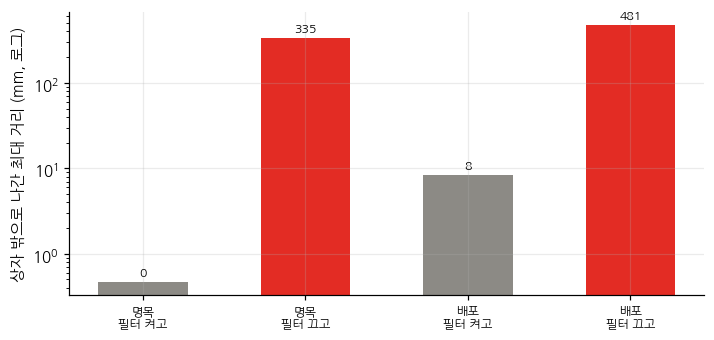

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ks = [(c, f) for c in COND for f in (True, False)]
lab = [f"{c}\n필터 {'켜고' if f else '끄고'}" for c, f in ks]
val = [max(BASE[k]["mx"], .05) for k in ks]
col = [GREY if f else RED for _, f in ks]
b = ax.bar(range(4), val, .55, color=col)
ax.set_yscale("log")
ax.set_xticks(range(4))
ax.set_xticklabels(lab, fontsize=8)
ax.set_ylabel("상자 밖으로 나간 최대 거리 (mm, 로그)")
for r, v in zip(b, val):
    ax.text(r.get_x() + r.get_width() / 2, v * 1.15,
            "0" if v < .1 else f"{v:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 필터의 비용

두 가지 비용이 있다. **계산 비용**과 **과제 비용**이다. 앞의 것은 3장 규약대로 재고, 뒤의 것은 위 표에 이미 나와 있다.

In [9]:
env = Pert(150, 1, **COND["배포"])
ot = torch.from_numpy(env.obs())
with torch.no_grad():
    a0 = POLICY.dist(ot).sample().numpy()
p0 = pusher_xy(env)

runs = {}
for lab, fn in (("정책 순전파", lambda: POLICY.dist(ot).sample()),
                ("CBF 필터", lambda: cbf_filter(p0, a0))):
    ts = []
    for i in range(500):
        t0 = time.perf_counter_ns()
        with torch.no_grad():
            fn()
        if i >= 50:
            ts.append((time.perf_counter_ns() - t0) / 1e3)
    runs[lab] = np.array(ts)

print(pad("항목", 16) + pad("p50 μs", 11, True)
      + pad("p99 μs", 11, True) + pad("정책 대비", 12, True))
base = np.percentile(runs["정책 순전파"], 50)
for lab, v in runs.items():
    p50 = np.percentile(v, 50)
    print(pad(lab, 16) + pad(f"{p50:.0f}", 11, True)
          + pad(f"{np.percentile(v, 99):.0f}", 11, True)
          + pad(f"{p50 / base * 100:.0f}%", 12, True))
print()
print("150 판을 한 번에 처리한 시간")

항목                 p50 μs     p99 μs   정책 대비
정책 순전파             192        285        100%
CBF 필터                 29         67         15%

150 판을 한 번에 처리한 시간


## 계수를 바꾸면

장벽 조건의 계수 α 가 **얼마나 일찍 개입할지**를 정한다. 작으면 멀리서부터 속도를 줄이고, 크면 경계 직전까지 그냥 두다가 급히 막는다.

In [10]:
print(pad("α", 8) + pad("성공률", 10, True)
      + pad("침범률", 10, True) + pad("이탈 최대", 12, True))
for al in (2., 6., 20., 60.):
    r = evaluate(POLICY, True, "배포", alpha=al)
    print(pad(f"{al:.0f}", 8) + pad(f"{r['ok']:.2f}", 10, True)
          + pad(f"{r['viol']:.3f}", 10, True)
          + pad(f"{r['mx']:.0f} mm", 12, True))
print()
print("배포 조건 — 지연이 있는 쪽")

α           성공률    침범률   이탈 최대


2             0.60     0.000        0 mm


6             0.74     0.240        8 mm


20            0.75     0.250       25 mm


60            0.75     0.257       28 mm

배포 조건 — 지연이 있는 쪽


## 필터에 기대어 배운 정책

여기까지는 이미 배운 정책에 필터를 얹었다. 필터를 **학습 중에** 끼면 어떻게 되는가. CBF-RL 이 묻는 질문이 이것이다.

- **필터 학습** — 학습 내내 필터를 끼고 배운다. 필터가 막아 주므로 스스로 조심할 이유가 없다
- **보상 학습** — 경계에 가까워지면 벌점을 받으며 배운다. 필터 없이 배운다

In [11]:
class SafeVec(Pert):
    """학습용 — 필터를 끼거나 경계 벌점을 주는 환경"""

    def __init__(self, n, seed=0, filt=False, pen=0., **kw):
        self.filt = filt
        self.pen = pen
        super().__init__(n, seed, **kw)

    def step(self, a):
        if self.filt:
            a = cbf_filter(pusher_xy(self), a)
        r, dn, sc = super().step(a)
        if self.pen:
            q = pusher_xy(self)
            slack = np.minimum(LIM[0] - np.abs(q[:, 0]),
                               LIM[1] - np.abs(q[:, 1]))
            r = r - self.pen * np.maximum(0., .04 - slack) / .04
        return r, dn, sc

In [12]:
def train_variant(kind, pen_w=.02, budget=250_000, seed=0,
                  n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = SafeVec(n, seed, filt=(kind == "필터 학습"),
                  pen=(pen_w if kind == "보상 학습" else 0.))
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLS = {"기준": POLICY}
for kind in ("필터 학습", "보상 학습"):
    POLS[kind] = train_variant(kind)
    print(f"{kind} 끝  ({time.time() - t0:.0f}s)")

필터 학습 끝  (66s)


보상 학습 끝  (131s)


In [13]:
TAB = {}
for k, pol in POLS.items():
    for c in COND:
        for f in (True, False):
            TAB[(k, c, f)] = evaluate(pol, f, c)

for c in COND:
    print(f"[{c} 조건]")
    print(pad("정책", 12) + pad("성공 켜고", 11, True)
          + pad("성공 끄고", 11, True) + pad("침범 끄고", 11, True)
          + pad("이탈 끄고", 12, True))
    for k in POLS:
        a, b = TAB[(k, c, True)], TAB[(k, c, False)]
        print(pad(k, 12) + pad(f"{a['ok']:.2f}", 11, True)
              + pad(f"{b['ok']:.2f}", 11, True)
              + pad(f"{b['viol']:.3f}", 11, True)
              + pad(f"{b['mx']:.0f} mm", 12, True))
    print()

[명목 조건]
정책          성공 켜고  성공 끄고  침범 끄고   이탈 끄고
기준               0.75       0.92      0.270      335 mm
필터 학습          0.84       0.83      0.153      452 mm
보상 학습          0.46       0.45      0.343      554 mm

[배포 조건]
정책          성공 켜고  성공 끄고  침범 끄고   이탈 끄고
기준               0.74       0.73      0.257      481 mm
필터 학습          0.13       0.10      0.727      681 mm
보상 학습          0.51       0.50      0.297      344 mm



## 정리

**필터는 싸다.** 부등식 하나에 변수 하나이므로 닫힌 형태로 풀리고, 정책 순전파의 15% 다. 마감 안에 넣을 수 있다.

**필터는 지연 없이는 완벽하고, 지연이 있으면 샌다.** 명목 0 mm, 배포 8 mm. 필터도 제어 고리 안에 있으므로 **안전 여유에 한 주기를 미리 빼 두어야 한다.**

**필터는 공짜가 아니다.** 상자가 작업 공간을 자르면 성공률이 0.92 에서 0.75 로 내려간다. α 를 줄여 더 안전하게 만들수록 더 많이 잘린다.

**필터가 지켜 준 정책은 안전한 정책이 아니다.** 필터를 떼면 기준보다 더 멀리 나간다.

**그러나 안전을 보상에 넣는 것만으로 해결되지도 않았다.** 상자가 과제와 다투는 한 벌점은 과제를 깎는다. 안전 집합을 그리는 일이 방법을 고르는 일보다 먼저다.

4부가 끝났다. 알아채고(12·13장), 대처하고(14장), 막는(15장) 세 층을 봤다. 5부는 이 시스템을 **여러 대로 늘리고 현장에서 고치는** 이야기로 간다.